# Model D — Multi-Scale CNN

In this notebook, we evaluate the effect of multi-scale feature extraction. Models A, B, and C used sequential convolutional blocks with a fixed kernel size of 3×3.

Model D uses parallel convolutional branches with kernel sizes of 3×3 and 5×5, followed by concatenation of their feature maps. The same training conditions are maintained for a fair comparison. The objective is to evaluate the effect of multi-scale feature extraction on aerial scene classification performance.

This experiment was inspired by the multi-scale feature fusion approach applied to the AID dataset by Das et al. (2026). Our architecture was developed from scratch using simpler parallel 3×3 and 5×5 convolutional branches.

In [1]:
from pathlib import Path
import sys
import json
import time
import shutil
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    f1_score ,
)

PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from project_utils import (
    EPOCHS,
    TARGET_CLASSES,
    RESULTS_DIR,
    FIGURES_DIR,
    ARTIFACTS_DIR,
    set_seed,
    load_datasets,
    build_multiscale_cnn,
)

print("Project root:", PROJECT_ROOT)

Project root: c:\Users\Asus\Desktop\AID-Scene_Classification


In [2]:
from project_utils import (
    EPOCHS,
    TARGET_CLASSES,
    RESULTS_DIR,
    FIGURES_DIR,
    ARTIFACTS_DIR,
    set_seed,
    load_datasets,
    build_multiscale_cnn,
)

In [3]:
set_seed()

train_ds, val_ds, test_ds = load_datasets()

for images, labels in train_ds.take(1):
    print("Images shape:", images.shape)
    print("Labels shape:", labels.shape)

Images shape: (32, 160, 160, 3)
Labels shape: (32,)


In [4]:
# Model D configuration: custom multi-scale CNN with parallel 3x3 and 5x5 convolutional branches

model_d_config = {
    "name": "model_d_multiscale",
    "stem_filters": 32,
    "branch_filters": 32,
    "kernel_sizes": [3, 5],
    "final_filters": 128,
    "dense_units": 64,
}

In [5]:
tf.keras.backend.clear_session()
set_seed()

model_d = build_multiscale_cnn(
    num_classes=len(TARGET_CLASSES),
    config=model_d_config,
)

model_d.summary()

model_d_params = model_d.count_params()

print(f"Total parameters: {model_d_params:,}")

Model: "model_d_multiscale"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 160, 160,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 160, 160,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 160, 160,  │        896 │ rescaling[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 160, 160,  │          0 │ conv2d[0][0]      │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 80, 80,    │          0 │ activation[0][0]  │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ branch_3x3 (Conv2D) │ (None, 80, 80,    │      9,248 │ max_pooling2d[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ branch_5x5 (Conv2D) │ (None, 80, 80,    │     25,632 │ max_pooling2d[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 80, 80,    │          0 │ branch_3x3[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 80, 80,    │          0 │ branch_5x5[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiscale_concate… │ (None, 80, 80,    │          0 │ activation_1[0][… │
│ (Concatenate)       │ 64)               │            │ activation_2[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 40, 40,    │          0 │ multiscale_conca… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 40, 40,    │     73,856 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 40, 40,    │          0 │ conv2d_1[0][0]    │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 20, 20,    │          0 │ activation_3[0][… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ max_pooling2d_2[… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │      8,256 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 10)        │        650 │ dense[0][0]       │
└─────────────────────┴───────────────────┴────────────┴─────────────────

 Total params: 118,538 (463.04 KB)

 Trainable params: 118,538 (463.04 KB)

 Non-trainable params: 0 (0.00 B)

Total parameters: 118,538


In [6]:
# Model D compile
model_d.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

In [8]:
# Model D training
start = time.time()

history_d = model_d.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
)

train_time_sec_d = time.time() - start

print(
    f"\nTraining time: {train_time_sec_d:.1f} "
    f"sec for {EPOCHS} epochs"
)

Epoch 1/15
77/77 ━━━━━━━━━━━━━━━━━━━━ 86s 1s/step - accuracy: 0.5195 - loss: 1.3207 - val_accuracy: 0.5303 - val_loss: 1.2947
Epoch 2/15
77/77 ━━━━━━━━━━━━━━━━━━━━ 94s 1s/step - accuracy: 0.5572 - loss: 1.2427 - val_accuracy: 0.5663 - val_loss: 1.1724
Epoch 3/15
77/77 ━━━━━━━━━━━━━━━━━━━━ 90s 1s/step - accuracy: 0.5560 - loss: 1.2318 - val_accuracy: 0.5530 - val_loss: 1.2458
Epoch 4/15
77/77 ━━━━━━━━━━━━━━━━━━━━ 87s 1s/step - accuracy: 0.5828 - loss: 1.1414 - val_accuracy: 0.5795 - val_loss: 1.0975
Epoch 5/15
77/77 ━━━━━━━━━━━━━━━━━━━━ 88s 1s/step - accuracy: 0.6006 - loss: 1.0868 - val_accuracy: 0.5341 - val_loss: 1.1479
Epoch 6/15
77/77 ━━━━━━━━━━━━━━━━━━━━ 86s 1s/step - accuracy: 0.5925 - loss: 1.0946 - val_accuracy: 0.6080 - val_loss: 1.0982
Epoch 7/15
77/77 ━━━━━━━━━━━━━━━━━━━━ 87s 1s/step - accuracy: 0.6185 - loss: 1.0366 - val_accuracy: 0.6212 - val_loss: 1.0058
Epoch 8/15
77/77 ━━━━━━━━━━━━━━━━━━━━ 91s 1s/step - accuracy: 0.6546 - loss: 0.9765 - val_accuracy: 0.6496 - val_loss:

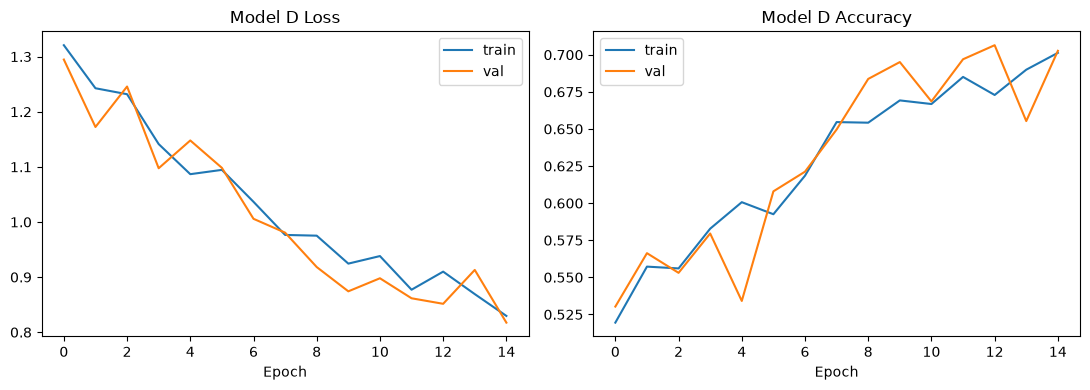

In [9]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(11, 4),
)

axes[0].plot(
    history_d.history["loss"],
    label="train",
)

axes[0].plot(
    history_d.history["val_loss"],
    label="val",
)

axes[0].set_title("Model D Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(
    history_d.history["accuracy"],
    label="train",
)

axes[1].plot(
    history_d.history["val_accuracy"],
    label="val",
)

axes[1].set_title("Model D Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()

plt.savefig(
    os.path.join(
        FIGURES_DIR,
        "model_d_curves.png",
    ),
    dpi=120,
)

plt.show()

Model D test accuracy: 0.6818 | test loss: 0.8439
Model D Macro F1: 0.6728


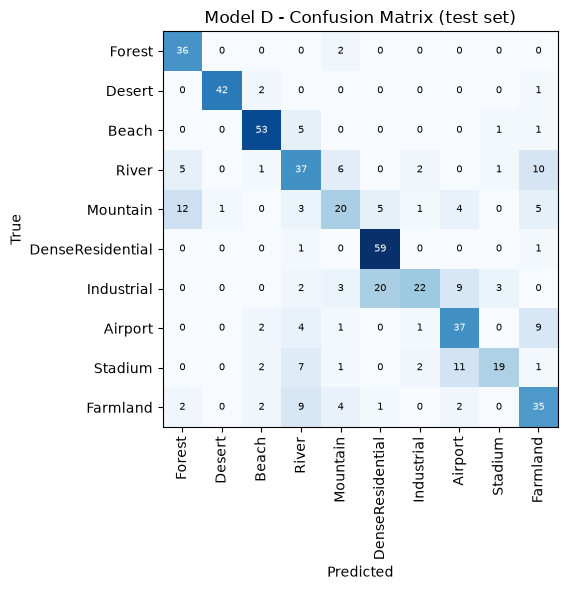

                  precision    recall  f1-score   support

          Forest       0.65      0.95      0.77        38
          Desert       0.98      0.93      0.95        45
           Beach       0.85      0.88      0.87        60
           River       0.54      0.60      0.57        62
        Mountain       0.54      0.39      0.45        51
DenseResidential       0.69      0.97      0.81        61
      Industrial       0.79      0.37      0.51        59
         Airport       0.59      0.69      0.63        54
         Stadium       0.79      0.44      0.57        43
        Farmland       0.56      0.64      0.59        55

        accuracy                           0.68       528
       macro avg       0.70      0.69      0.67       528
    weighted avg       0.69      0.68      0.67       528



In [10]:
test_loss_d, test_acc_d = model_d.evaluate(
    test_ds,
    verbose=0,
)

print(
    f"Model D test accuracy: {test_acc_d:.4f} "
    f"| test loss: {test_loss_d:.4f}"
)

y_true_d = []
y_pred_d = []

for imgs, labels in test_ds:
    probs_d = model_d.predict(
        imgs,
        verbose=0,
    )

    y_true_d.extend(
        labels.numpy().tolist()
    )

    y_pred_d.extend(
        np.argmax(
            probs_d,
            axis=1,
        ).tolist()
    )

macro_f1_d = f1_score(
    y_true_d,
    y_pred_d,
    average="macro",
)

print(
    f"Model D Macro F1: {macro_f1_d:.4f}"
)

cm_d = confusion_matrix(y_true_d, y_pred_d)

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm_d, cmap="Blues")

ax.set_xticks(range(len(TARGET_CLASSES)))
ax.set_xticklabels(TARGET_CLASSES, rotation=90)

ax.set_yticks(range(len(TARGET_CLASSES)))
ax.set_yticklabels(TARGET_CLASSES)

ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Model D - Confusion Matrix (test set)")

for i in range(cm_d.shape[0]):
    for j in range(cm_d.shape[1]):
        ax.text(
            j,
            i,
            cm_d[i, j],
            ha="center",
            va="center",
            color="white" if cm_d[i, j] > cm_d.max() / 2 else "black",
            fontsize=7,
        )

plt.tight_layout()

plt.savefig(
    os.path.join(
        FIGURES_DIR,
        "model_d_confusion_matrix.png",
    ),
    dpi=120,
)

plt.show()

print(
    classification_report(
        y_true_d,
        y_pred_d,
        target_names=TARGET_CLASSES,
    )
)

In [12]:
model_d.save(
    os.path.join(
        ARTIFACTS_DIR,
        "model_d_multiscale.keras",
    )
)

model_d_params = model_d.count_params()

history_out_d = {
    "model": "model_d_multiscale",
    "config": model_d_config,
    "epochs": EPOCHS,
    "train_time_sec": float(train_time_sec_d),
    "n_params": int(model_d_params),
    "test_accuracy": float(test_acc_d),
    "test_loss": float(test_loss_d),
    "macro_f1": float(macro_f1_d),
    "history": {
        k: [float(v) for v in vals]
        for k, vals in history_d.history.items()
    },
}

with open(
    os.path.join(
        RESULTS_DIR,
        "model_d_history.json",
    ),
    "w",
) as f:
    json.dump(
        history_out_d,
        f,
        indent=2,
    )

print(
    "Saved model to",
    os.path.join(
        ARTIFACTS_DIR,
        "model_d_multiscale.keras",
    ),
)

print(
    "Saved training history to",
    os.path.join(
        RESULTS_DIR,
        "model_d_history.json",
    ),
)

Saved model to C:\Users\Asus\Desktop\AID-Scene_Classification\artifacts\model_d_multiscale.keras
Saved training history to C:\Users\Asus\Desktop\AID-Scene_Classification\results\model_d_history.json


## Findings

Overall, Model D achieved the lowest test loss and the highest macro F1-score among Models A–D. It provided the best balance between accuracy, class-level performance, and generalization at this stage, although its test accuracy remained comparable to Model B.

The model performed particularly well on Desert, Beach, and DenseResidential. It also improved the Mountain F1-score from 0.11 in Model B to 0.45, while Industrial and Stadium remained relatively difficult.